# Imports 

In [36]:
import pandas as pd
from collections import defaultdict
import sys
import os
import shutil as sh
import urllib
import tarfile
import numpy as np
import math
import seaborn as sns
import glob, os
import importlib
import gzip
import MDAnalysis as mda
import nglview as nv
import requests
import json
from biopandas.pdb import PandasPdb
from Bio import AlignIO
import re
from io import StringIO
import itertools

from sklearn.calibration import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, roc_auc_score

from sklearn.naive_bayes import CategoricalNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.spatial import ConvexHull


# Methods 

In [35]:
def load_data(path):
    """
    Load data from the path were it was stored.
    """
    if not os.path.isfile(path):
        raise FileNotFoundError(f"The file at {path} was not found.")
    return pd.read_csv(path)

def separate_features_target(df, target, columns_to_remove=None):
    if columns_to_remove is None:
        columns_to_remove=[]
    columns_to_remove=set(columns_to_remove + [target])
    X=df.drop(columns=[col for col in columns_to_remove if col in df.columns])
    y=df[target]
    return X, y

def train_tuned_model(model, X_train, X_test, y_train, y_test, cmap="Blues", scale=True):
    """
    Train and evaluate a tuned model using AUC and confusion matrix.

    Parameters:
    - model: fitted estimator (e.g., best estimator from GridSearchCV)
    - X, y: features and labels
    - cmap: heatmap color
    - scale: whether to apply StandardScaler
    - test_size: fraction for test set
    - random_state: reproducibility

    Returns:
    - auc score (float)
    """
    # Optional scaling (only if model benefits from it)
    if scale:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

    # Train and predict
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    cm_df = pd.DataFrame(
        cm, 
        columns=['Predicted: 0', 'Predicted: 1'], 
        index=['Actual: 0', 'Actual: 1']
    )
    sns.heatmap(cm_df, annot=True, fmt='d', cmap=cmap)
    plt.title(f'Confusion Matrix: {model.__class__.__name__}')
    plt.show()

    # Compute and print AUC
    try:
        auc = roc_auc_score(y_test, y_pred)
        print(f"Model: {model.__class__.__name__} | AUC: {auc:.4f}")
    except ValueError:
        auc = None
        print(f"AUC could not be computed (only one class predicted).")

    return auc, y_test, y_pred


# Load Data

In [23]:
df = load_data("/home/user_stel/AISB/Project/dataset/processed_dataset.csv")
print(df)

       domain residue_name  IBS  residue_number  convhull_vertex  \
0          PH          ASN  0.0            19.0              0.0   
1          PH          ASN  0.0            75.0              1.0   
2          PH          ASN  0.0            78.0              1.0   
3          PH          ASN  0.0            92.0              1.0   
4          PH          ASN  0.0            93.0              1.0   
...       ...          ...  ...             ...              ...   
183885    PLA          CYS  0.0            91.0              0.0   
183886    PLA          CYS  0.0            96.0              0.0   
183887    PLA          CYS  0.0            98.0              0.0   
183888    PLA          CYS  0.0           105.0              0.0   
183889    PLA          CYS  1.0           124.0              0.0   

        is_hydrophobic_protrusion  is_co_insertable  exposed  type  
0                             0.0               0.0      1.0   4.0  
1                             0.0            

In [24]:
# split features and target 
columns_to_remove = ['domain', 'residue_name', 'residue_number']
X, y = separate_features_target(df, target='IBS', columns_to_remove=columns_to_remove)

# Hyperparameter Tuning

In [5]:
models = {
    'LogisticRegression-elasticnet': LogisticRegression(
        penalty='elasticnet', solver='saga', random_state=0, max_iter=10000
    ),
    'RandomForest': RandomForestClassifier(random_state=0),
    'CategoricalNB': CategoricalNB()
    }

In [34]:
# Your dictionary of hyperparameters
param_grid = {
    'LogisticRegression-elasticnet': {
        'C': [0.01, 0.1, 1, 10],
        'l1_ratio': [0.0, 0.25, 0.5, 0.75, 1.0],
        'penalty': ['elasticnet'],
        'solver': ['saga'],
        'max_iter': [10000]  # Needed for convergence in elasticnet
    },
    'RandomForest': {
        'n_estimators': [100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    },
    'CategoricalNB': {
        'alpha': [0.0, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
    }
}

# Mapping names to classifier constructors
models = {
    'LogisticRegression-elasticnet': LogisticRegression,
    'RandomForest': RandomForestClassifier,
    'CategoricalNB': CategoricalNB
}

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Store all results
grid_results = {}

# Loop through each model + param set
for name, params in param_grid.items():
    print(f"Running GridSearchCV for {name}...")

    model = models[name]()  # Create the model
    clf = GridSearchCV(estimator=model, param_grid=params, cv=5, scoring='accuracy', n_jobs=-1)
    
    clf.fit(X_train, y_train)
    
    # Save results
    grid_results[name] = {
        'best_estimator': clf.best_estimator_,
        'best_params': clf.best_params_,
        'best_score': clf.best_score_,
        'cv_results': clf.cv_results_
    }


Running GridSearchCV for LogisticRegression-elasticnet...


GridSearchCV(cv=5, estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10],
                         'l1_ratio': [0.0, 0.25, 0.5, 0.75, 1.0],
                         'max_iter': [10000], 'penalty': ['elasticnet'],
                         'solver': ['saga']},
             scoring='accuracy')

Running GridSearchCV for RandomForest...


GridSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='accuracy')

Running GridSearchCV for CategoricalNB...


GridSearchCV(cv=5, estimator=CategoricalNB(), n_jobs=-1,
             param_grid={'alpha': [0.0, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]},
             scoring='accuracy')

# Train tuned models 


Evaluating best model for: LogisticRegression-elasticnet


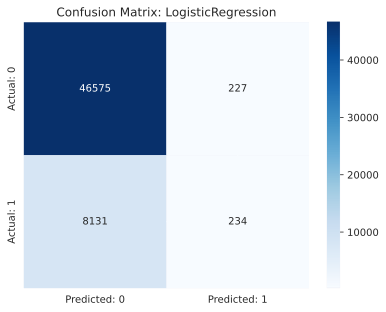

Model: LogisticRegression | AUC: 0.5116

Evaluating best model for: RandomForest


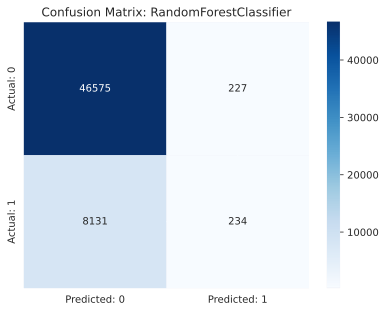

Model: RandomForestClassifier | AUC: 0.5116

Evaluating best model for: CategoricalNB


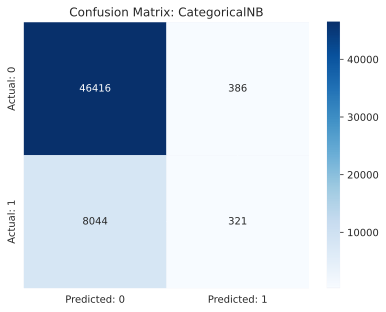

Model: CategoricalNB | AUC: 0.5151

AUC Summary:
                           Model       AUC
2                  CategoricalNB  0.515063
0  LogisticRegression-elasticnet  0.511562
1                   RandomForest  0.511562


In [39]:
model_auc_scores = []

for model_name, result in grid_results.items():
    best_model = result['best_estimator']
    print(f"\nEvaluating best model for: {model_name}")
    scale_flag = model_name.startswith("Logistic")
    
    auc, y_test, y_pred = train_tuned_model(
        best_model, X_train, X_test, y_train, y_test, scale=scale_flag
    )
    
    model_auc_scores.append({
        'Model': model_name,
        'AUC': auc
    })

# Create DataFrame
auc_summary_df = pd.DataFrame(model_auc_scores)
print("\nAUC Summary:")
print(auc_summary_df.sort_values(by='AUC', ascending=False))
